#### Geopandas Homework - Anna Horton
Below is my analysis of the relationship between green space, Mardi Gras parade routes, and the wards of New Orleans, Louisiana. I want to understand if there is a relationship between the amount of green space in a ward and the prevalence of the parade route in that area. I will eventually also involve the demographics of the wards to identify if this is a trend that could be attributed to the demographic makeup of the neighborhoods. I specifically want to look at the biggest ward and the smallest ward and understand the differences between them. 

##### First step: upload and filter the data for just the attributes that I need

In [87]:
## uploading the packages
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## uploading the data itself
routes = gpd.read_file("Mardi_Gras_Routes_20261003.geojson")
greenspace = gpd.read_file("Open_Greenspace_20261003.geojson")
wards = gpd.read_file("Wards_20261003.geojson")

## making sure all of the projections are the same - getting some weird results further down
routes = routes.to_crs(epsg = 32615)
greenspace = greenspace.to_crs(epsg = 32615)
wards = wards.to_crs(epsg = 32615)


In [88]:
routes = routes[["parade", "location", "shape_stlength", "geometry"]]

## dropping the NaN values from the dataframe
routes.dropna(subset = ["parade"], how = "all", inplace = True)
routes.columns = ["name", "location", "shape_stlength", "geometry"]

In [89]:
greenspace = greenspace[["name", "geometry", "shape_starea"]]
## dropping the NaN values from the dataframe
greenspace.dropna(subset = ["name"], how = "all", inplace = True)

In [90]:
wards = wards[["ward", "shape_area", "geometry"]]
wards.columns = ["name", "shape_area", "geometry"]

##### Plotting the various geometries to visualize the variables

<Axes: >

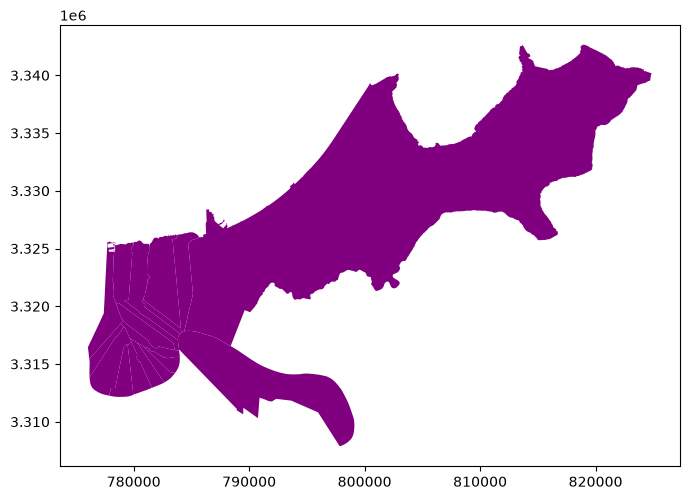

In [91]:
## plotting each of the earlier layers so that I can understand exactly where I am looking at
### plotting the ward boundaries
fig, ax = plt.subplots(figsize=(8,7))
wards.plot(ax=ax, color="purple")


<Axes: >

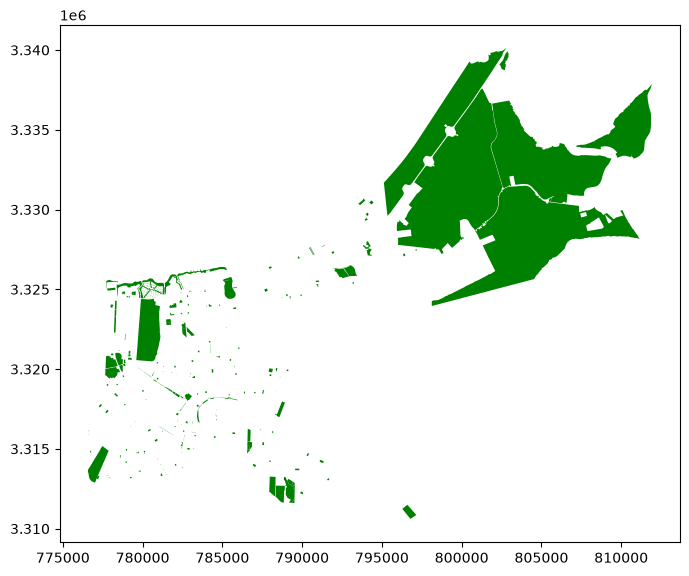

In [92]:
### plotting the greenspace boundaries
fig, ax = plt.subplots(figsize=(8,7))
greenspace.plot(ax=ax, color="green")

<Axes: >

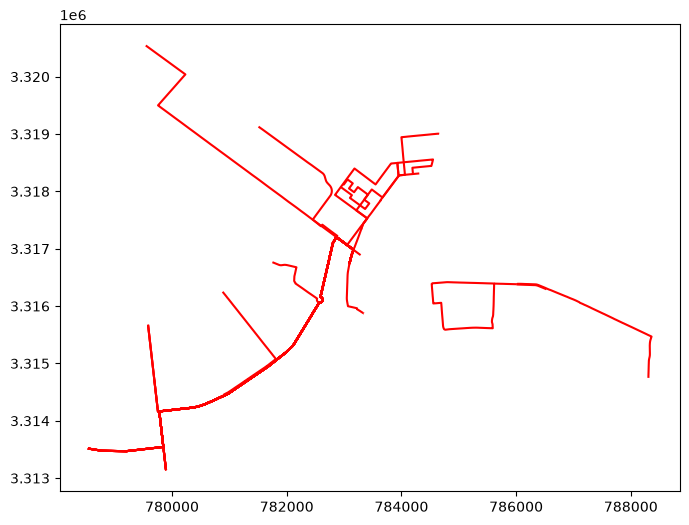

In [93]:
### plotting the parade routes
fig, ax = plt.subplots(figsize=(8,7))
routes.plot(ax=ax, color="red")


<Axes: >

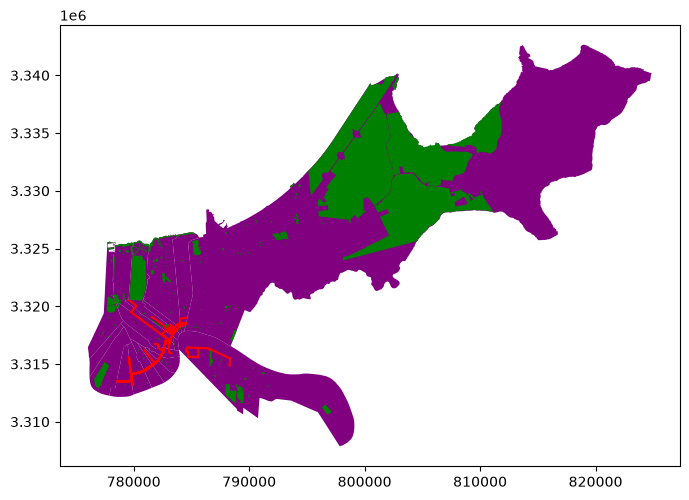

In [94]:
## plotting them all on top of each other to see if my analysis is doing anything helpful
fig, ax = plt.subplots(figsize=(8,7))
wards.plot(ax=ax, color="purple")
greenspace.plot(ax=ax, color="green")
routes.plot(ax=ax, color="red")

## visualized: there is some overlap of the parade routes and the ward boundaries, as well as some minimal overlap with the greenspace

#### Analysis
What I want to get at is the following: 
1) Are New Orleans parades using their greenspace appropriately?
2) Where can parade routes expand to ensure that they are able to maximize their use of greenspace?

In [95]:
## first step: create a spatial join between the routes and the wards to how many routes are within each ward
ward_c_routes = gpd.sjoin(wards, routes, how = "left", predicate = "contains")
ward_c_routes
## spatial join with a meaningful tabular result

# from this analysis there are only two wards that posess a parade route completely contained, and those are wards 5 and 15

,name_left,shape_area,geometry,index_right,name_right,location,shape_stlength
0,6,17965648.880237851,"MULTIPOLYGON (((784126.664 3317714.657, 784016...",NaN,NaN,NaN,NaN
1,11,37330838.03291522,"MULTIPOLYGON (((781365.55 3315279.831, 781485....",NaN,NaN,NaN,NaN
2,12,47373994.02730675,"MULTIPOLYGON (((780381.941 3315285.816, 780423...",NaN,NaN,NaN,NaN
3,13,51777794.015902705,"MULTIPOLYGON (((779485.152 3316604.1, 779497.6...",NaN,NaN,NaN,NaN
4,16,31769146.82387539,"MULTIPOLYGON (((778564.518 3317396.03, 778558....",NaN,NaN,NaN,NaN
5,10,26209810.956029069,"MULTIPOLYGON (((782646.496 3313393.301, 782643...",NaN,NaN,NaN,NaN
6,15,578581641.529585,"MULTIPOLYGON (((788379.883 3316540.771, 788385...",14.0,NOMTOC,West Bank,25847.150251192994
7,5,112452404.97319485,"MULTIPOLYGON (((780665.922 3325622, 780698.435...",6.0,Barkus,Downtown,5768.4592363558468
8,1,23545965.274778757,"MULTIPOLYGON (((781427.4 3316161.688, 781601.3...",NaN,NaN,NaN,NaN
9,4,110248963.76638122,"MULTIPOLYGON (((779920.979 3325476.843, 779929...",NaN,NaN,NaN,NaN


In [96]:
## what about intersection?
wards_union = wards.geometry.union_all()
ward_i_routes = routes[routes.geometry.intersects(wards_union)] ## this analysis tells me the parades that overlap each ward
## layer one

## testing how many routes intersect with each ward
wards["route_count"] = wards.geometry.apply(lambda geom: routes.geometry.intersects(geom).sum())
wards.sort_values("route_count", ascending = False)

,name,shape_area,geometry,route_count
16,3,64319974.820429273,"MULTIPOLYGON (((783475.595 3316643.303, 783527...",31
5,10,26209810.956029069,"MULTIPOLYGON (((782646.496 3313393.301, 782643...",30
15,2,37961901.92523744,"MULTIPOLYGON (((781645.43 3316511.746, 781690....",30
8,1,23545965.274778757,"MULTIPOLYGON (((781427.4 3316161.688, 781601.3...",30
1,11,37330838.03291522,"MULTIPOLYGON (((781365.55 3315279.831, 781485....",29
2,12,47373994.02730675,"MULTIPOLYGON (((780381.941 3315285.816, 780423...",29
3,13,51777794.015902705,"MULTIPOLYGON (((779485.152 3316604.1, 779497.6...",15
7,5,112452404.97319485,"MULTIPOLYGON (((780665.922 3325622, 780698.435...",6
9,4,110248963.76638122,"MULTIPOLYGON (((779920.979 3325476.843, 779929...",5
11,8,105797659.11738931,"MULTIPOLYGON (((785671.153 3325966.081, 785676...",3


In [ ]:
## now I want to know which wards have the most greenspace
greenspace.dropna(subset = ["name"])
mask = greenspace["name"].str.contains("Park")
greenspace = greenspace[mask]

## creating a spatial join between the wards and the greenspace layer
green_wards = gpd.sjoin(wards, greenspace, predicate = "contains")
green_wards = green_wards.sort_values("name_left")
green_wards.groupby("name_left")
green_wards

## based on this analysis, ward 5 has the most greenspace 

,name_left,shape_area,geometry,route_count,index_right,name_right,shape_starea
8,1,23545965.274778757,"MULTIPOLYGON (((781427.4 3316161.688, 781601.3...",30,1520,Camp Street Finger Park,23851.892093741426
8,1,23545965.274778757,"MULTIPOLYGON (((781427.4 3316161.688, 781601.3...",30,3265,Parkerson Place,11613.958221057717
5,10,26209810.956029069,"MULTIPOLYGON (((782646.496 3313393.301, 782643...",30,2180,Sophie Wright Park,8570.0136703229673
1,11,37330838.03291522,"MULTIPOLYGON (((781365.55 3315279.831, 781485....",29,3775,McDonogh Zachery Park,11761.59672900222
2,12,47373994.02730675,"MULTIPOLYGON (((780381.941 3315285.816, 780423...",29,576,Amelia Park,3993.5051438900709
2,12,47373994.02730675,"MULTIPOLYGON (((780381.941 3315285.816, 780423...",29,2257,Little General Taylor Park,2592.8447145823843
3,13,51777794.015902705,"MULTIPOLYGON (((779485.152 3316604.1, 779497.6...",15,4061,Cadiz Park,8810.8517092790826
10,14,100139851.59973092,"MULTIPOLYGON (((779520.549 3317533.719, 779644...",0,481,Gilmore Park,20587.348199715008
10,14,100139851.59973092,"MULTIPOLYGON (((779520.549 3317533.719, 779644...",0,3947,Broad Place Park,3929.6363926159061
10,14,100139851.59973092,"MULTIPOLYGON (((779520.549 3317533.719, 779644...",0,4127,Audubon Park,13985137.807483474


In [ ]:
## next, I will create a buffer around the greenspaces and see if there is a possibility that there could be some crossing there
green_buffer = greenspace.geometry.buffer(distance = 500) ## decided on a distance of 500 feet for my buffer, seems to be a good availability for expansion

## creating the crossing layer
crossing_the_green = green_buffer.geometry.crosses(ward_i_routes, align = True) ## this explains if parade routes that already intersect the wards also cross a 500 foot buffer around any greenspace that has a title
print(crossing_the_green.value_counts())
## layer two

## there is no overlap!

False    98
Name: count, dtype: int64


In [ ]:
## given that there are no wards even within a 500 foot buffer of a greenspace, the time might have come to increase the buffer
green_buffer_1 = greenspace.geometry.buffer(distance = 2000)
wards_close_to_green1 = green_buffer_1.geometry.within(wards)
wards_close_to_green1.value_counts()

## even with a quadrupled buffer, there is simply no overlap between New Orleans wards and greenspace 

/var/folders/gr/m2n_2p5571g1k1fldyhfmx980000gn/T/ipykernel_28586/615125020.py:3: UserWarning: The indices of the left and right GeoSeries' are not equal, and therefore they will be aligned (reordering and/or introducing missing values) before executing the operation. If this alignment is the desired behaviour, you can silence this warning by passing 'align=True'. If you don't want alignment and protect yourself of accidentally aligning, you can pass 'align=False'.
  wards_close_to_green1 = green_buffer_1.geometry.within(wards)


False    79
Name: count, dtype: int64

#### As of right now, it seems that the parade routes that already intersect with wards do not cross with instances of greenspace (even with a 500 foot buffer and a 2000 foot buffer).

The results of my analysis demonstrate that there is no use of greenspace by the New Orleans parade routes. They are content with pushing people into the sides of the streets and possibly creating hazardous situations. Based on the above analysis, I am going to demonstrate which wards and which parades are the largest, and so should thus expand into the greenspaces or shift their paths to overlap with the geometric extent of the parks and similar distributed throughout the city. 

In [ ]:
## based on the green_wards layer
## I used the parade length as a proxy for the parade size (based on distance)
routes = routes.sort_values("shape_stlength")
long_routes = routes[0:5]

## also sorted the green_wards (so wards that I know possess some variety of named greenspace) by the size and selected the first five
wards_big = wards.sort_values("shape_area", ascending = False)
big_wards = wards_big[0:5]

In [ ]:
## testing to see if these routes overlap more than one ward
ward_five = ward_c_routes[(ward_c_routes["name_left"] == 5)]
ward_five

,name_left,shape_area,geometry,index_right,name_right,location,shape_stlength
